# Lab: Ensemble Learning for Heart Disease Prediction — TASKS

Complete each TODO cell. The notebook is designed to be challenging but follows the same structure as the solution notebook.


## Setup

In [2]:
# Core libraries
import os
import glob
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset download
try:
    import kagglehub
except ImportError as exc:
    raise ImportError(
        "kagglehub is not installed. Install it with: pip install kagglehub"
    ) from exc

# scikit-learn utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [3]:
def make_onehot_encoder():
    """Return a version-compatible OneHotEncoder."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_bagging(base_estimator, **kwargs):
    """Return a version-compatible BaggingClassifier."""
    try:
        return BaggingClassifier(estimator=base_estimator, **kwargs)
    except TypeError:
        return BaggingClassifier(base_estimator=base_estimator, **kwargs)


def make_adaboost(base_estimator=None, **kwargs):
    """Return a version-compatible AdaBoostClassifier."""
    if base_estimator is None:
        return AdaBoostClassifier(**kwargs)
    try:
        return AdaBoostClassifier(estimator=base_estimator, **kwargs)
    except TypeError:
        return AdaBoostClassifier(base_estimator=base_estimator, **kwargs)


## 1. Load dataset

In [4]:
# Download latest version using the exact KaggleHub dataset requested
path = kagglehub.dataset_download("oktayrdeki/heart-disease")
print("Path to dataset files:", path)

csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
print("CSV files found:", [os.path.basename(f) for f in csv_files])
if not csv_files:
    raise FileNotFoundError(f"No CSV files found under {path}")

# If there are several CSVs, the largest one is normally the main dataset
csv_path = max(csv_files, key=os.path.getsize)
print("Using:", csv_path)
df = pd.read_csv(csv_path)

display(df.head())
print("Dataset shape:", df.shape)

100%|██████████| 568k/568k [00:00<00:00, 1.37MB/s]

Extracting files...
Path to dataset files: /Users/sam/.cache/kagglehub/datasets/oktayrdeki/heart-disease/versions/1
CSV files found: ['heart_disease.csv']
Using: /Users/sam/.cache/kagglehub/datasets/oktayrdeki/heart-disease/versions/1/heart_disease.csv


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


Dataset shape: (10000, 21)


## 2. Inspect data and detect target

In [5]:
# ---- Inspect the raw data ----
print("Shape:", df.shape)
display(df.dtypes.to_frame("dtype").T)

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"\nColumns with missing values: {len(missing)}")
display(missing.to_frame("n_missing").assign(pct=lambda m: (m["n_missing"] / len(df) * 100).round(2)))

print("Duplicate rows:", df.duplicated().sum())

candidate_targets = [
    "HeartDisease", "heart_disease", "target", "Target", "class", "Class",
    "output", "Outcome", "Disease", "disease", "Heart Disease Status"
]

# ---- Detect the target column ----
target_col = next((c for c in candidate_targets if c in df.columns), None)
if target_col is None:
    raise ValueError(f"No target column found. Columns are: {list(df.columns)}")
print("\nTarget column:", target_col)
print(df[target_col].value_counts(dropna=False))

# Rows with no label are useless for supervised learning; exact duplicates add no information
df = df.dropna(subset=[target_col]).drop_duplicates().reset_index(drop=True)
print("Shape after dropping unlabelled/duplicate rows:", df.shape)

# ---- Define X and y ----
X = df.drop(columns=[target_col])
y_raw = df[target_col]

if pd.api.types.is_numeric_dtype(y_raw) and set(y_raw.unique()) <= {0, 1}:
    y = y_raw.astype(int)
else:
    positive_words = {"yes", "1", "true", "presence", "present", "disease", "positive"}
    normalised = y_raw.astype(str).str.strip().str.lower()
    if normalised.isin(positive_words).any():
        y = normalised.isin(positive_words).astype(int)
    else:  # fallback: alphabetical encoding
        y = pd.Series(LabelEncoder().fit_transform(y_raw), index=y_raw.index)
    print("Label mapping:", dict(zip(y_raw, y)))

print("\nClass balance (1 = heart disease):")
print(y.value_counts(normalize=True).round(3))

# ---- Feature types ----
numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()
print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)


Shape: (10000, 21)


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
dtype,float64,str,float64,float64,str,str,str,str,float64,str,...,str,str,str,float64,str,float64,float64,float64,float64,str



Columns with missing values: 20


,n_missing,pct
Alcohol Consumption,2586,25.86
Cholesterol Level,30,0.30
Sugar Consumption,30,0.30
Diabetes,30,0.30
Age,29,0.29
High LDL Cholesterol,26,0.26
CRP Level,26,0.26
Triglyceride Level,26,0.26
High Blood Pressure,26,0.26
Sleep Hours,25,0.25


Duplicate rows: 0

Target column: Heart Disease Status
Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64
Shape after dropping unlabelled/duplicate rows: (10000, 21)
Label mapping: {'No': 0, 'Yes': 1}

Class balance (1 = heart disease):
Heart Disease Status
0    0.8
1    0.2
Name: proportion, dtype: float64

Numeric features: ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']
Categorical features: ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']


## 3. Preprocessing pipeline

In [6]:
from sklearn.base import clone

# Stratified split keeps the same disease/no-disease ratio in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Positive rate  train: %.3f  test: %.3f" % (y_train.mean(), y_test.mean()))

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_onehot_encoder()),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


def make_pipe(clf):
    """Fresh preprocessing + classifier pipeline (clone so models never share fitted state)."""
    return Pipeline(steps=[("prep", clone(preprocessor)), ("clf", clf)])


Train: (8000, 20)  Test: (2000, 20)
Positive rate  train: 0.200  test: 0.200


## 4. Evaluation utility

In [7]:
def evaluate_model(name, model, X_eval, y_eval):
    """Evaluate a fitted classification model."""
    start = time.perf_counter()
    y_pred = model.predict(X_eval)
    elapsed = time.perf_counter() - start
    latency_ms_per_sample = (elapsed / max(len(X_eval), 1)) * 1000

    auc = np.nan
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)[:, 1]
        auc = roc_auc_score(y_eval, y_score)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_eval)
        auc = roc_auc_score(y_eval, y_score)

    return {
        "model": name,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "roc_auc": auc,
        "latency_ms_per_sample": latency_ms_per_sample
    }


## 5. Baseline and single models

In [8]:
single_models = {
    "Dummy Majority": make_pipe(DummyClassifier(strategy="most_frequent")),
    "Logistic Regression": make_pipe(LogisticRegression(max_iter=2000)),
    "Decision Tree": make_pipe(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    "kNN": make_pipe(KNeighborsClassifier(n_neighbors=15)),
}

rows = []
for name, model in single_models.items():
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_s = time.perf_counter() - t0
    res = evaluate_model(name, model, X_test, y_test)
    res["fit_seconds"] = fit_s
    rows.append(res)

single_results = pd.DataFrame(rows)
display(single_results.round(4))


,model,accuracy,precision,recall,f1,roc_auc,latency_ms_per_sample,fit_seconds
0,Dummy Majority,0.8000,0.0000,0.000,0.0000,0.5000,0.0021,0.0346
1,Logistic Regression,0.8000,0.0000,0.000,0.0000,0.4863,0.0017,0.0275
2,Decision Tree,0.6565,0.1979,0.235,0.2149,0.4984,0.0017,0.0818
3,kNN,0.7945,0.0000,0.000,0.0000,0.4917,0.0354,0.0159


## 6. Manual bootstrap experiment

,sample,unique_prop,oob_prop
mean,12.0000,0.6315,0.3685
std,7.3598,0.0026,0.0026
min,0.0000,0.6254,0.3651
max,24.0000,0.6349,0.3746


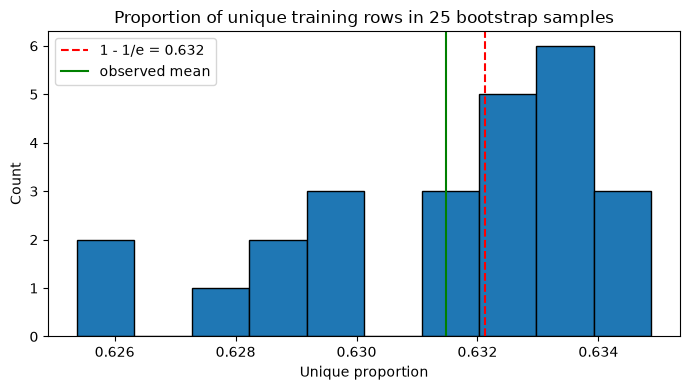

In [9]:
B = 25
n = len(X_train)
rng = np.random.default_rng(RANDOM_STATE)

records = []
for b in range(B):
    idx = rng.integers(0, n, size=n)          # draw n rows WITH replacement
    unique_prop = len(np.unique(idx)) / n     # share of original rows that appear at least once
    records.append({"sample": b, "unique_prop": unique_prop, "oob_prop": 1 - unique_prop})

bootstrap_summary = pd.DataFrame(records)
display(bootstrap_summary.describe().loc[["mean", "std", "min", "max"]].round(4))

theory = 1 - np.exp(-1)  # ~0.632
plt.figure(figsize=(7, 4))
plt.hist(bootstrap_summary["unique_prop"], bins=10, edgecolor="black")
plt.axvline(theory, color="red", linestyle="--", label=f"1 - 1/e = {theory:.3f}")
plt.axvline(bootstrap_summary["unique_prop"].mean(), color="green", label="observed mean")
plt.title(f"Proportion of unique training rows in {B} bootstrap samples")
plt.xlabel("Unique proportion"); plt.ylabel("Count"); plt.legend(); plt.tight_layout(); plt.show()


## 7. Ensemble models

In [10]:
ensemble_models = {
    "Bagging (Trees)": make_pipe(make_bagging(
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
    "Random Forest": make_pipe(RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    "Extra Trees": make_pipe(ExtraTreesClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    "AdaBoost": make_pipe(make_adaboost(
        DecisionTreeClassifier(max_depth=1),           # decision stumps
        n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE)),
    "Gradient Boosting": make_pipe(GradientBoostingClassifier(random_state=RANDOM_STATE)),
    "Soft Voting": make_pipe(VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=2000)),
            ("dt", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
            ("knn", KNeighborsClassifier(n_neighbors=15)),
            ("rf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
        ],
        voting="soft")),
    "Stacking": make_pipe(StackingClassifier(
        estimators=[
            ("rf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
            ("gb", GradientBoostingClassifier(random_state=RANDOM_STATE)),
            ("knn", KNeighborsClassifier(n_neighbors=15)),
        ],
        final_estimator=LogisticRegression(max_iter=2000),
        cv=5, n_jobs=-1)),
}

rows = []
for name, model in ensemble_models.items():
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_s = time.perf_counter() - t0
    res = evaluate_model(name, model, X_test, y_test)
    res["fit_seconds"] = fit_s
    rows.append(res)
    print(f"{name:<20} fitted in {fit_s:6.2f}s")

ensemble_results = pd.DataFrame(rows)
display(ensemble_results.round(4))


Bagging (Trees)      fitted in   2.48s
Random Forest        fitted in   0.34s
Extra Trees          fitted in   0.25s
AdaBoost             fitted in   0.94s
Gradient Boosting    fitted in   1.19s
Soft Voting          fitted in   0.24s
Stacking             fitted in   3.04s


,model,accuracy,precision,recall,f1,roc_auc,latency_ms_per_sample,fit_seconds
0,Bagging (Trees),0.7995,0.0,0.0000,0.000,0.5141,0.0233,2.4760
1,Random Forest,0.8000,0.0,0.0000,0.000,0.4947,0.0143,0.3426
2,Extra Trees,0.8005,1.0,0.0025,0.005,0.5210,0.0139,0.2462
3,AdaBoost,0.8000,0.0,0.0000,0.000,0.4690,0.0074,0.9446
4,Gradient Boosting,0.8005,1.0,0.0025,0.005,0.4814,0.0023,1.1919
5,Soft Voting,0.8000,0.0,0.0000,0.000,0.4946,0.0841,0.2418
6,Stacking,0.8000,0.0,0.0000,0.000,0.4902,0.0231,3.0370


## 8. Compare single models and ensembles

,model,accuracy,precision,recall,f1,roc_auc,latency_ms_per_sample,fit_seconds,family
2,Decision Tree,0.6565,0.1979,0.2350,0.2149,0.4984,0.0017,0.0818,single
6,Extra Trees,0.8005,1.0000,0.0025,0.0050,0.5210,0.0139,0.2462,ensemble
8,Gradient Boosting,0.8005,1.0000,0.0025,0.0050,0.4814,0.0023,1.1919,ensemble
0,Dummy Majority,0.8000,0.0000,0.0000,0.0000,0.5000,0.0021,0.0346,single
1,Logistic Regression,0.8000,0.0000,0.0000,0.0000,0.4863,0.0017,0.0275,single
3,kNN,0.7945,0.0000,0.0000,0.0000,0.4917,0.0354,0.0159,single
4,Bagging (Trees),0.7995,0.0000,0.0000,0.0000,0.5141,0.0233,2.4760,ensemble
5,Random Forest,0.8000,0.0000,0.0000,0.0000,0.4947,0.0143,0.3426,ensemble
7,AdaBoost,0.8000,0.0000,0.0000,0.0000,0.4690,0.0074,0.9446,ensemble
9,Soft Voting,0.8000,0.0000,0.0000,0.0000,0.4946,0.0841,0.2418,ensemble


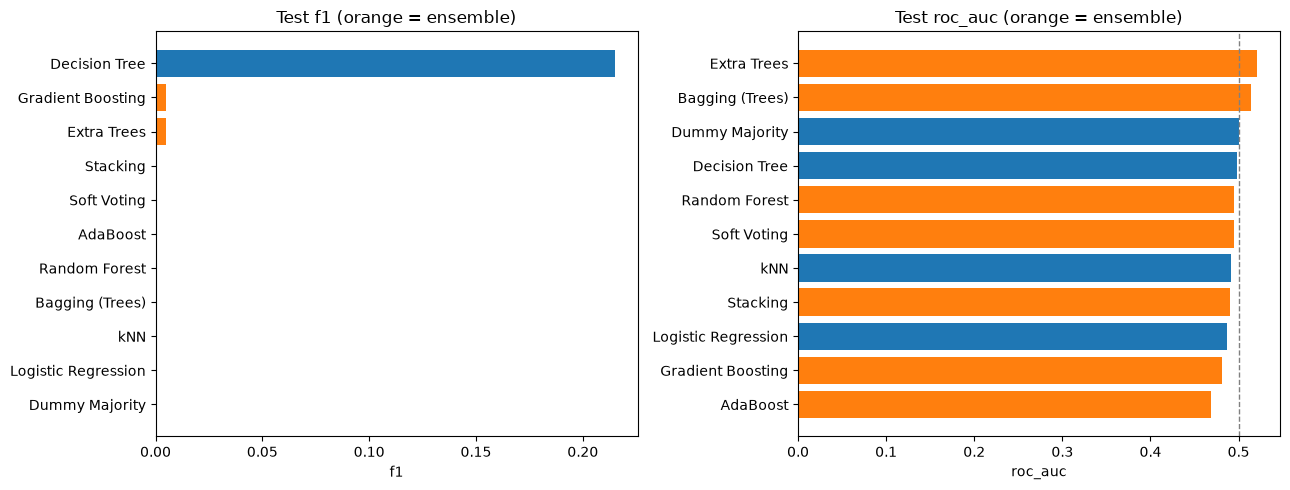

In [11]:
single_results["family"] = "single"
ensemble_results["family"] = "ensemble"
all_results = pd.concat([single_results, ensemble_results], ignore_index=True)
all_models = {**single_models, **ensemble_models}

display(all_results.sort_values("f1", ascending=False).round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ["f1", "roc_auc"]):
    d = all_results.sort_values(metric)
    colors = ["tab:orange" if f == "ensemble" else "tab:blue" for f in d["family"]]
    ax.barh(d["model"], d[metric], color=colors)
    ax.set_title(f"Test {metric} (orange = ensemble)")
    ax.set_xlabel(metric)
    if metric == "roc_auc":
        ax.axvline(0.5, color="grey", linestyle="--", linewidth=1)
plt.tight_layout(); plt.show()


## 9. Cross-validation

,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
model,,,,,,,,,,
Logistic Regression,0.8000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5115,0.0221
Decision Tree,0.6645,0.0072,0.1924,0.0181,0.2131,0.0299,0.2020,0.0231,0.4952,0.0119
Random Forest,0.8000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4979,0.0089
Gradient Boosting,0.7985,0.0010,0.2167,0.1944,0.0025,0.0023,0.0049,0.0046,0.5011,0.0173
Soft Voting,0.8000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5143,0.0190


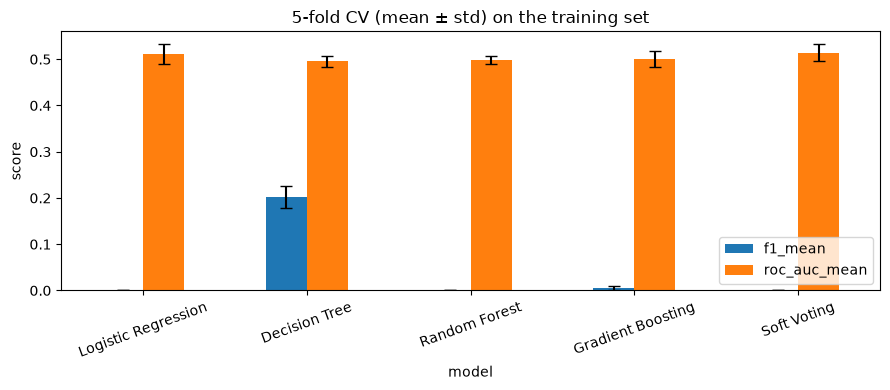

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_model_names = ["Logistic Regression", "Decision Tree", "Random Forest",
                  "Gradient Boosting", "Soft Voting"]

cv_rows = []
for name in cv_model_names:
    scores = cross_validate(all_models[name], X_train, y_train, cv=cv,
                            scoring=scoring, n_jobs=-1)
    row = {"model": name}
    for m in scoring:
        row[f"{m}_mean"] = scores[f"test_{m}"].mean()
        row[f"{m}_std"] = scores[f"test_{m}"].std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).set_index("model")
display(cv_results.round(4))

cv_results[["f1_mean", "roc_auc_mean"]].plot.bar(
    yerr=cv_results[["f1_std", "roc_auc_std"]].values.T, figsize=(9, 4), capsize=4)
plt.title("5-fold CV (mean ± std) on the training set"); plt.ylabel("score")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()


## 10. Ensemble diversity analysis

Disagreement rate:

$$\text{disagreement}(A,B)=\frac{1}{N}\sum_{i=1}^{N}\mathbf{1}[\hat{y}_{A,i} \neq \hat{y}_{B,i}]$$

Base learner test accuracy / positive-prediction rate:


,accuracy,pred_positive_rate
lr,0.8000,0.0000
dt,0.7980,0.0050
knn,0.7945,0.0055
rf,0.8000,0.0000


Pairwise disagreement:


,lr,dt,knn,rf
lr,0.000,0.005,0.006,0.000
dt,0.005,0.000,0.010,0.005
knn,0.006,0.010,0.000,0.006
rf,0.000,0.005,0.006,0.000


Prediction correlation:


,lr,dt,knn,rf
lr,NaN,NaN,NaN,NaN
dt,NaN,1.000,-0.005,NaN
knn,NaN,-0.005,1.000,NaN
rf,NaN,NaN,NaN,NaN


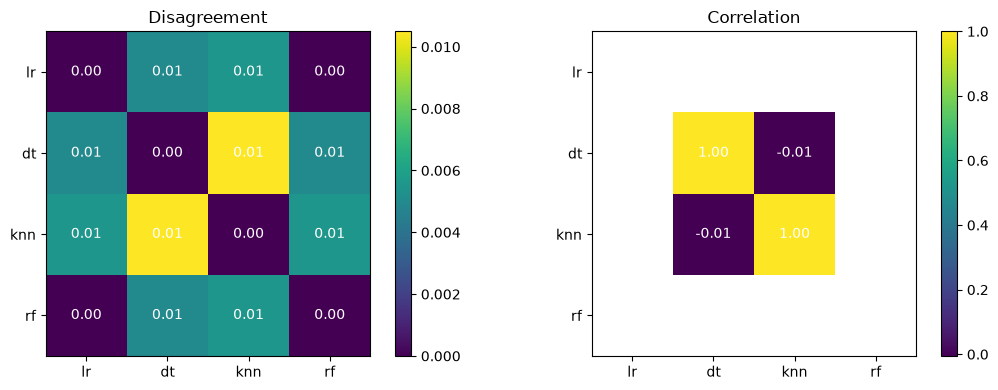

Mean pairwise disagreement: 0.005
Rule of thumb: near 0 -> learners are redundant; diversity only helps if the learners that disagree are also individually better than chance.


In [13]:
voting_pipe = ensemble_models["Soft Voting"]
Xt_test = voting_pipe.named_steps["prep"].transform(X_test)          # base learners see preprocessed data
base_learners = voting_pipe.named_steps["clf"].named_estimators_

# 1. Base-learner predictions on the test set
base_preds = pd.DataFrame({name: est.predict(Xt_test) for name, est in base_learners.items()})
print("Base learner test accuracy / positive-prediction rate:")
display(pd.DataFrame({
    "accuracy": (base_preds.values == y_test.values[:, None]).mean(axis=0),
    "pred_positive_rate": base_preds.mean(axis=0).values,
}, index=base_preds.columns).round(4))

# 2. Pairwise disagreement
names = base_preds.columns
disagreement = pd.DataFrame(
    [[(base_preds[a] != base_preds[b]).mean() for b in names] for a in names],
    index=names, columns=names)
print("Pairwise disagreement:")
display(disagreement.round(3))

# 3. Correlation of predictions (NaN if a learner predicts a single class everywhere)
corr = base_preds.corr()
print("Prediction correlation:")
display(corr.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, mat, title in [(axes[0], disagreement, "Disagreement"), (axes[1], corr, "Correlation")]:
    im = ax.imshow(mat.values.astype(float), cmap="viridis")
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
    for i in range(len(names)):
        for j in range(len(names)):
            v = mat.values[i, j]
            ax.text(j, i, "nan" if pd.isna(v) else f"{v:.2f}", ha="center", va="center", color="white")
    ax.set_title(title); fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

# 4. Quick interpretation
off_diag = disagreement.values[~np.eye(len(names), dtype=bool)]
print(f"Mean pairwise disagreement: {off_diag.mean():.3f}")
print("Rule of thumb: near 0 -> learners are redundant; diversity only helps if the "
      "learners that disagree are also individually better than chance.")


## 11. Feature importance

Top 15 built-in (impurity-based) importances:


,importance
num__BMI,0.0863
num__Homocysteine Level,0.0853
num__Sleep Hours,0.0849
num__CRP Level,0.0834
num__Triglyceride Level,0.0820
num__Cholesterol Level,0.0787
num__Fasting Blood Sugar,0.0754
num__Age,0.0739
num__Blood Pressure,0.0729
cat__Alcohol Consumption_Medium,0.0116


Permutation importance (drop in test ROC-AUC when a column is shuffled):


,mean_drop_auc,std
Diabetes,0.0042,0.0038
Family Heart Disease,0.0038,0.0041
Cholesterol Level,0.0032,0.0051
Blood Pressure,0.0019,0.0049
CRP Level,0.0004,0.0064
Exercise Habits,0.0003,0.0038
Sugar Consumption,-0.0001,0.0048
Low HDL Cholesterol,-0.0009,0.0046
Gender,-0.0029,0.0048
Homocysteine Level,-0.0037,0.0037


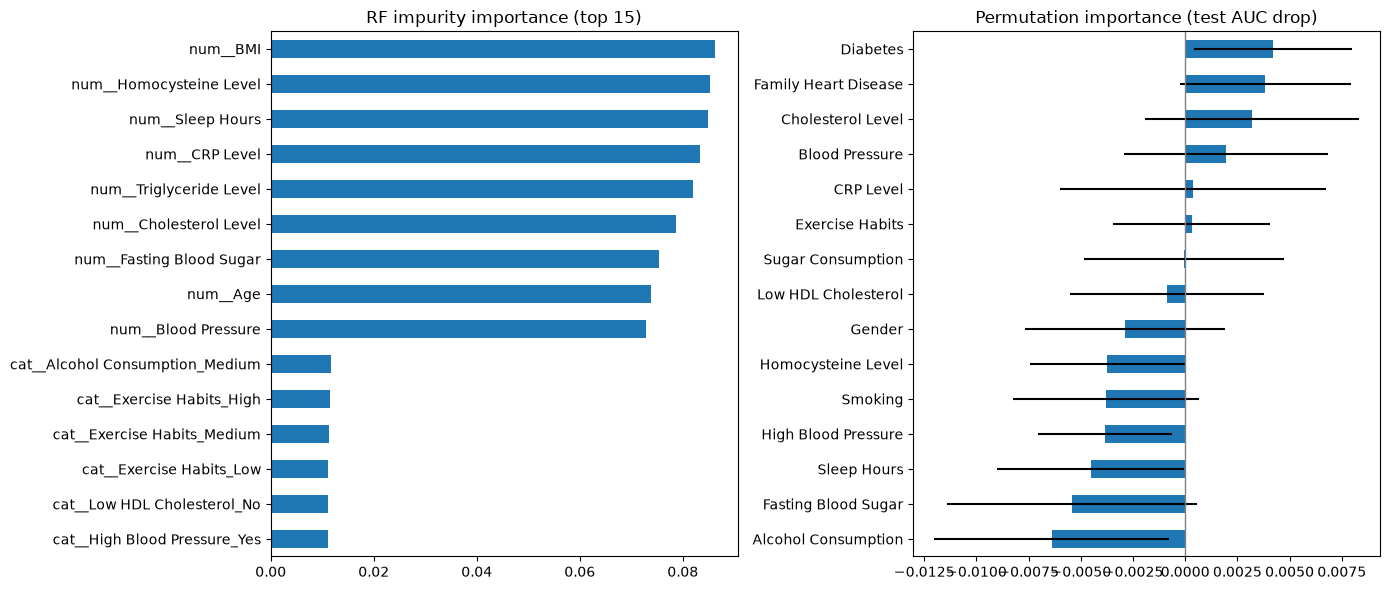

In [14]:
rf_pipe = ensemble_models["Random Forest"]

# Challenge: recover feature names after one-hot encoding
feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
rf_importance = (pd.Series(rf_pipe.named_steps["clf"].feature_importances_, index=feature_names)
                   .sort_values(ascending=False))
print("Top 15 built-in (impurity-based) importances:")
display(rf_importance.head(15).round(4).to_frame("importance"))

# Permutation importance on the TEST set, using the whole pipeline -> original column names
perm = permutation_importance(rf_pipe, X_test, y_test, scoring="roc_auc",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_importance = (pd.DataFrame({"mean_drop_auc": perm.importances_mean,
                                 "std": perm.importances_std}, index=X_test.columns)
                     .sort_values("mean_drop_auc", ascending=False))
print("Permutation importance (drop in test ROC-AUC when a column is shuffled):")
display(perm_importance.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_importance.head(15)[::-1].plot.barh(ax=axes[0], title="RF impurity importance (top 15)")
perm_importance.head(15)[::-1]["mean_drop_auc"].plot.barh(
    ax=axes[1], xerr=perm_importance.head(15)[::-1]["std"], title="Permutation importance (test AUC drop)")
axes[1].axvline(0, color="grey", linewidth=1)
plt.tight_layout(); plt.show()


## 12. Threshold tuning for clinical sensitivity

Best ROC-AUC model: Extra Trees
Threshold sweep on out-of-fold TRAIN probabilities:


,threshold,precision,recall,f1,accuracy,pred_positive_rate
0,0.10,0.199,0.976,0.331,0.211,0.980
1,0.15,0.201,0.832,0.324,0.306,0.826
2,0.20,0.205,0.566,0.301,0.476,0.551
3,0.25,0.204,0.293,0.241,0.630,0.288
4,0.30,0.204,0.127,0.156,0.726,0.125
5,0.35,0.202,0.044,0.073,0.774,0.044
6,0.40,0.197,0.017,0.031,0.790,0.017
7,0.45,0.234,0.007,0.013,0.797,0.006
8,0.50,0.250,0.002,0.005,0.799,0.002
9,0.55,0.000,0.000,0.000,0.800,0.000


Chosen threshold (max OOF F2): 0.05  (F2 = 0.555)


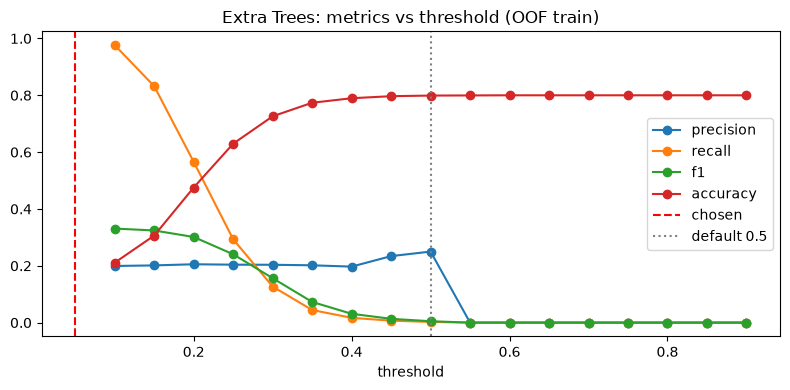

Test-set metrics at 0.50 vs chosen threshold:


,threshold,precision,recall,f1,accuracy,pred_positive_rate
0,0.50,1.0,0.002,0.005,0.8,0.0
1,0.05,0.2,1.000,0.333,0.2,1.0


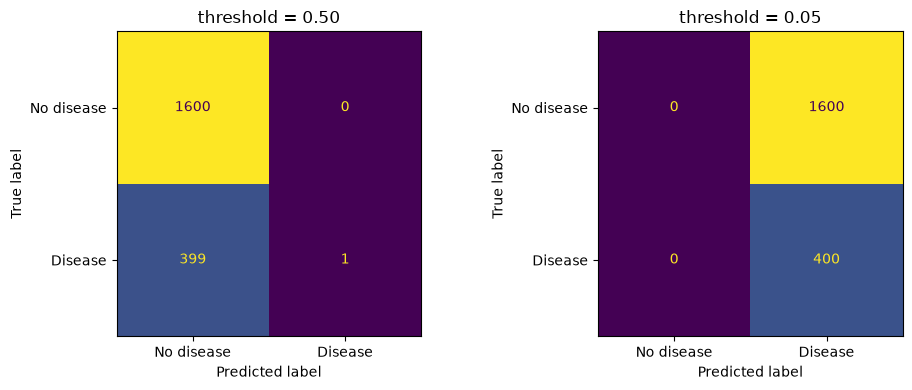

In [15]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

# Best ROC-AUC model (ignore the dummy baseline)
candidates = all_results[all_results["model"] != "Dummy Majority"]
best_name = candidates.loc[candidates["roc_auc"].idxmax(), "model"]
best_model = all_models[best_name]
print("Best ROC-AUC model:", best_name)

# Choose the threshold on OUT-OF-FOLD training probabilities, not on the test set,
# so the final test numbers are an honest estimate.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = cross_val_predict(clone(best_model), X_train, y_train, cv=cv,
                              method="predict_proba", n_jobs=-1)[:, 1]

def threshold_table(y_true, proba, thresholds):
    out = []
    for t in thresholds:
        p = (proba >= t).astype(int)
        out.append({"threshold": round(t, 2),
                    "precision": precision_score(y_true, p, zero_division=0),
                    "recall": recall_score(y_true, p, zero_division=0),
                    "f1": f1_score(y_true, p, zero_division=0),
                    "accuracy": accuracy_score(y_true, p),
                    "pred_positive_rate": p.mean()})
    return pd.DataFrame(out)

thresholds = np.arange(0.10, 0.91, 0.05)
thr_train = threshold_table(y_train, oof_proba, thresholds)
print("Threshold sweep on out-of-fold TRAIN probabilities:")
display(thr_train.round(3))

# Clinical rule: maximise F2 (recall counts twice as much as precision, because a missed
# patient is worse than a false alarm). Search on a fine 0.01 grid for a precise choice.
from sklearn.metrics import fbeta_score
fine = np.arange(0.05, 0.951, 0.01)
f2 = [fbeta_score(y_train, (oof_proba >= t).astype(int), beta=2, zero_division=0) for t in fine]
chosen_threshold = round(float(fine[int(np.argmax(f2))]), 2)
print(f"Chosen threshold (max OOF F2): {chosen_threshold:.2f}  (F2 = {max(f2):.3f})")

thr_train.set_index("threshold")[["precision", "recall", "f1", "accuracy"]].plot(figsize=(8, 4), marker="o")
plt.axvline(chosen_threshold, color="red", linestyle="--", label="chosen")
plt.axvline(0.5, color="grey", linestyle=":", label="default 0.5")
plt.title(f"{best_name}: metrics vs threshold (OOF train)"); plt.legend(); plt.tight_layout(); plt.show()

# Apply to the TEST set
test_proba = best_model.predict_proba(X_test)[:, 1]
print("Test-set metrics at 0.50 vs chosen threshold:")
display(threshold_table(y_test, test_proba, [0.5, chosen_threshold]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, t in zip(axes, [0.5, chosen_threshold]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, (test_proba >= t).astype(int)),
                           display_labels=["No disease", "Disease"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"threshold = {t:.2f}")
plt.tight_layout(); plt.show()


## 13. Harder challenge: tune Random Forest

In [16]:
param_distributions = {
    "clf__n_estimators": [100, 200, 300, 500],
    "clf__max_depth": [None, 5, 10, 15, 20],
    "clf__min_samples_leaf": [1, 2, 4, 8, 16],
    "clf__max_features": ["sqrt", "log2", 0.5],
    "clf__class_weight": [None, "balanced", "balanced_subsample"],
}

rf_search = RandomizedSearchCV(
    make_pipe(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
    param_distributions=param_distributions,
    n_iter=20, scoring="f1",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
t0 = time.perf_counter()
rf_search.fit(X_train, y_train)
print(f"Search took {time.perf_counter() - t0:.1f}s")
print("Best CV F1:", round(rf_search.best_score_, 4))
print("Best params:", rf_search.best_params_)

tuned_rf = rf_search.best_estimator_
tuned_res = evaluate_model("Tuned Random Forest", tuned_rf, X_test, y_test)
tuned_res["family"] = "ensemble"
comparison = pd.DataFrame([all_results.set_index("model").loc["Random Forest"].to_dict() | {"model": "Random Forest"},
                           tuned_res]).set_index("model")
display(comparison[["accuracy", "precision", "recall", "f1", "roc_auc"]].round(4))

all_results = pd.concat([all_results, pd.DataFrame([tuned_res])], ignore_index=True)
all_models["Tuned Random Forest"] = tuned_rf

top = pd.DataFrame(rf_search.cv_results_).sort_values("rank_test_score").head(5)
display(top[["mean_test_score", "std_test_score"] + [c for c in top.columns if c.startswith("param_")]])


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Search took 18.7s
Best CV F1: 0.2414
Best params: {'clf__n_estimators': 500, 'clf__min_samples_leaf': 4, 'clf__max_features': 0.5, 'clf__max_depth': 5, 'clf__class_weight': 'balanced_subsample'}


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Random Forest,0.800,0.0000,0.0000,0.0000,0.4947
Tuned Random Forest,0.623,0.1906,0.2725,0.2243,0.4696


,mean_test_score,std_test_score,param_clf__n_estimators,param_clf__min_samples_leaf,param_clf__max_features,param_clf__max_depth,param_clf__class_weight
14,0.241437,0.007367,500,4,0.5,5,balanced_subsample
11,0.152051,0.016835,200,8,0.5,15,balanced
18,0.149056,0.009524,500,2,log2,10,balanced
17,0.140824,0.014272,300,1,sqrt,10,balanced
3,0.089958,0.010580,100,4,0.5,20,balanced


## 14. Manual error analysis

outcome
FP    1600
TP     400
Name: count, dtype: int64

False negatives (missed disease) — 0 rows, lowest probability first:


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,y_true,proba,y_pred,outcome,correct


False positives (false alarms) — 1600 rows, highest probability first:


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,y_true,proba,y_pred,outcome,correct
4524,60.0,Male,155.0,193.0,High,Yes,Yes,No,37.104084,No,...,Low,189.0,98.0,13.178463,18.194664,0,0.490000,1,FP,False
3952,59.0,Male,140.0,210.0,Medium,No,Yes,Yes,35.793197,Yes,...,Medium,261.0,104.0,4.689320,17.679139,0,0.486667,1,FP,False
7932,54.0,Female,123.0,264.0,Medium,Yes,No,No,33.946301,No,...,Low,346.0,111.0,13.120198,5.778444,0,0.480000,1,FP,False
3884,79.0,Female,169.0,289.0,Low,Yes,Yes,No,33.344942,No,...,Medium,123.0,118.0,6.457967,11.803469,0,0.473333,1,FP,False
7554,77.0,Female,173.0,185.0,Low,Yes,Yes,No,31.646569,No,...,High,203.0,119.0,2.837162,6.950857,0,0.456667,1,FP,False
1824,57.0,Male,163.0,294.0,Medium,No,Yes,Yes,27.816528,No,...,High,295.0,153.0,0.123388,11.480048,0,0.456667,1,FP,False
5512,35.0,Female,168.0,298.0,Medium,Yes,No,Yes,37.573543,No,...,High,258.0,107.0,5.032450,NaN,0,0.453333,1,FP,False
164,72.0,Female,167.0,241.0,High,Yes,Yes,Yes,21.921762,No,...,Medium,360.0,130.0,12.922964,13.035945,0,0.450000,1,FP,False
2938,66.0,Male,151.0,293.0,High,No,Yes,Yes,23.222708,Yes,...,High,309.0,156.0,4.519487,6.639624,0,0.450000,1,FP,False
7031,72.0,Female,124.0,248.0,High,No,Yes,Yes,23.592572,No,...,High,389.0,113.0,5.714141,19.513296,0,0.446667,1,FP,False


Numeric feature means by outcome:


...

,n,disease_rate,error_rate
Alcohol Consumption,,,
High,491,0.230,0.770
Low,503,0.197,0.803
Medium,473,0.209,0.791
NaN,533,0.167,0.833



Stress Level


,n,disease_rate,error_rate
Stress Level,,,
High,629,0.178,0.822
Low,651,0.201,0.799
Medium,717,0.219,0.781
NaN,3,0.000,1.000



Sugar Consumption


,n,disease_rate,error_rate
Sugar Consumption,,,
High,681,0.188,0.812
Low,680,0.215,0.785
Medium,634,0.197,0.803
NaN,5,0.200,0.800


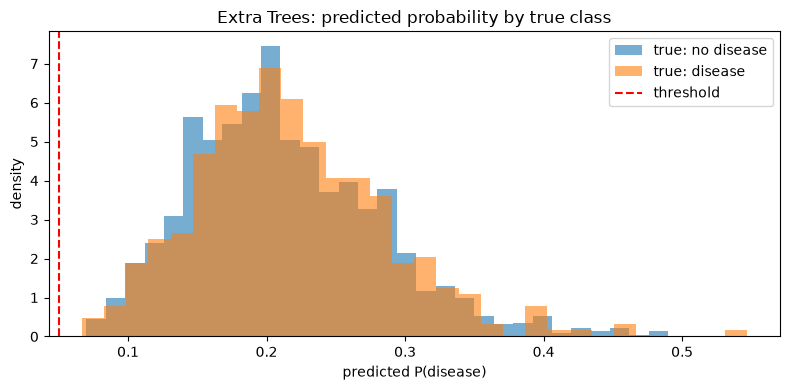

In [17]:
# Use the threshold-tuned best model from Section 12
err = X_test.copy()
err["y_true"] = y_test.values
err["proba"] = test_proba
err["y_pred"] = (test_proba >= chosen_threshold).astype(int)
err["outcome"] = np.select(
    [(err.y_true == 1) & (err.y_pred == 1), (err.y_true == 0) & (err.y_pred == 0),
     (err.y_true == 0) & (err.y_pred == 1), (err.y_true == 1) & (err.y_pred == 0)],
    ["TP", "TN", "FP", "FN"], default="?")
err["correct"] = err.y_true == err.y_pred
print(err["outcome"].value_counts())

false_negatives = err[err.outcome == "FN"].sort_values("proba")                    # most confident misses first
false_positives = err[err.outcome == "FP"].sort_values("proba", ascending=False)
print(f"\nFalse negatives (missed disease) — {len(false_negatives)} rows, lowest probability first:")
display(false_negatives.head(10))
print(f"False positives (false alarms) — {len(false_positives)} rows, highest probability first:")
display(false_positives.head(10))

# Numeric features: mean value per outcome group
print("Numeric feature means by outcome:")
display(err.groupby("outcome")[numeric_features].mean().round(2).T)

# Categorical features: positive-class rate and error rate per category
for col in categorical_features:
    tab = err.groupby(col, dropna=False).agg(n=("correct", "size"),
                                             disease_rate=("y_true", "mean"),
                                             error_rate=("correct", lambda s: 1 - s.mean()))
    print(f"\n{col}"); display(tab.round(3))

# Do the probabilities actually separate the classes?
plt.figure(figsize=(8, 4))
plt.hist(err.loc[err.y_true == 0, "proba"], bins=30, alpha=0.6, label="true: no disease", density=True)
plt.hist(err.loc[err.y_true == 1, "proba"], bins=30, alpha=0.6, label="true: disease", density=True)
plt.axvline(chosen_threshold, color="red", linestyle="--", label="threshold")
plt.xlabel("predicted P(disease)"); plt.ylabel("density"); plt.legend()
plt.title(f"{best_name}: predicted probability by true class"); plt.tight_layout(); plt.show()


## Written conclusion

Write a concise conclusion answering:

1. Did ensemble models outperform single models?
2. Which ensemble method worked best and why?
3. Was there useful diversity among base learners?
4. How did threshold tuning change clinical recall?
5. Which model would you deploy and what trade-off would you mention?

A strong answer should discuss F1, recall, ROC-AUC, latency, error analysis, and whether false negatives are more costly than false positives for heart disease screening.
